In [111]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [112]:
df = pd.read_csv("C:\\Users\\WELCOME\\Downloads\\Ice_cream selling data.csv")

In [113]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Temperature (°C)         49 non-null     float64
 1   Ice Cream Sales (units)  49 non-null     float64
dtypes: float64(2)
memory usage: 912.0 bytes


In [114]:
df.corr()

,Temperature (°C),Ice Cream Sales (units)
Temperature (°C),1.000000,-0.175184
Ice Cream Sales (units),-0.175184,1.000000


In [115]:
df.head()

,Temperature (°C),Ice Cream Sales (units)
0,-4.662263,41.842986
1,-4.316559,34.661120
2,-4.213985,39.383001
3,-3.949661,37.539845
4,-3.578554,32.284531


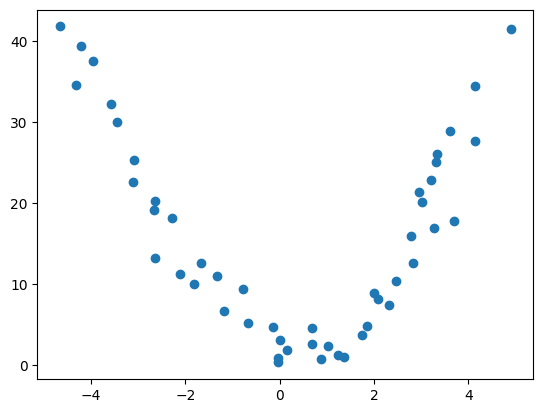

In [116]:
plt.scatter(df['Temperature (°C)'],df['Ice Cream Sales (units)'])

In [117]:
pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [118]:
from sklearn.model_selection import train_test_split

#### Polynomial Regression

In [119]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

#### Metrics

In [120]:

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

#### Feature and Target

In [121]:
X = df[['Temperature (°C)']]
y = df['Ice Cream Sales (units)']

#### Train-Test Split

In [122]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [123]:
y_train

12    11.218294
4     32.284531
34     7.412094
8     19.226970
3     37.539845
6     22.635401
40    22.839406
41    16.983279
46    34.530743
15    10.957731
9     20.279679
16     6.689123
24     2.576782
33     8.170735
30     3.782570
0     41.842986
43    26.104740
32     8.943823
5     30.001138
29     0.953115
11    18.123991
36    15.996620
1     34.661120
21     0.897603
2     39.383001
37    12.568237
35    10.336631
23     1.931416
39    20.114413
10    13.275828
22     3.165600
18     5.210163
48    41.514822
20     0.328626
7     25.365022
42    25.142082
14    12.615181
28     1.292361
38    21.342916
Name: Ice Cream Sales (units), dtype: float64


### Convert to Polynomial Features

In [ ]:
poly = PolynomialFeatures(degree=4) # degree can be 1,2,3,4,5
X_train_poly=poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [125]:
X_train_poly

array([[ 1.00000000e+00, -2.11186969e+00,  4.45999359e+00,
        -9.41892528e+00,  1.98915428e+01],
       [ 1.00000000e+00, -3.57855372e+00,  1.28060467e+01,
        -4.58271260e+01,  1.63994832e+02],
       [ 1.00000000e+00,  2.31859124e+00,  5.37586534e+00,
         1.24644343e+01,  2.88999281e+01],
       [ 1.00000000e+00, -2.67246083e+00,  7.14204687e+00,
        -1.90868405e+01,  5.10088335e+01],
       [ 1.00000000e+00, -3.94966109e+00,  1.55998227e+01,
        -6.16140128e+01,  2.43354469e+02],
       [ 1.00000000e+00, -3.10844012e+00,  9.66239999e+00,
        -3.00349918e+01,  9.33619735e+01],
       [ 1.00000000e+00,  3.21136614e+00,  1.03128725e+01,
         3.31184096e+01,  1.06355339e+02],
       [ 1.00000000e+00,  3.27004407e+00,  1.06931882e+01,
         3.49671967e+01,  1.14344274e+02],
       [ 1.00000000e+00,  4.13086796e+00,  1.70640701e+01,
         7.04894205e+01,  2.91182489e+02],
       [ 1.00000000e+00, -1.32637898e+00,  1.75928121e+00,
        -2.33347362e+00

### Model Creation and training

In [126]:
model=LinearRegression()
model.fit(X_train_poly,y_train) # learns the pattern(mx+c) from xtrain and ytrain

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### Predictions

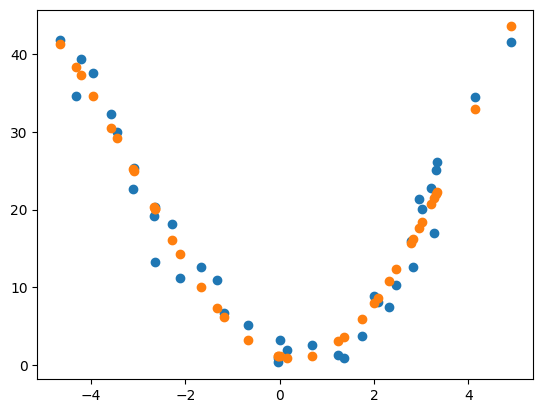

In [127]:
y_pred_train = model.predict(X_train_poly)
plt.scatter(X_train_poly[:,1],y_train)
plt.scatter(X_train_poly[:,1],y_pred_train)

In [128]:
y_pred_test = model.predict(X_test_poly)
test_score=r2_score(y_test,y_pred_test)
print("test score:",test_score)

test score: 0.8054468908427623


In [129]:
y_pred_train = model.predict(X_train_poly)
train_score=r2_score(y_train,y_pred_train)
print("train score:",train_score)

train score: 0.9590068634754769


#### Metrics

In [130]:
mse = mean_squared_error(y_test,y_pred_test)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test,y_pred_test)
r2=r2_score(y_test,y_pred_test)

In [131]:
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("Mean Absolute Error (MAE):", mae)
print("R² Score:", r2)

Mean Squared Error (MSE): 18.444159664446097
Root Mean Squared Error (RMSE): 4.29466642062525
Mean Absolute Error (MAE): 3.43761854085144
R² Score: 0.8054468908427623


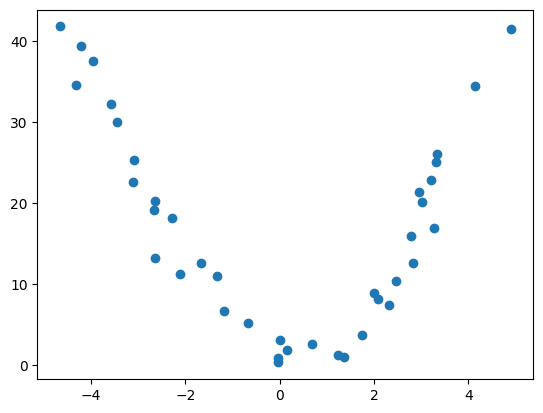

In [132]:
plt.scatter(X_train,y_train)

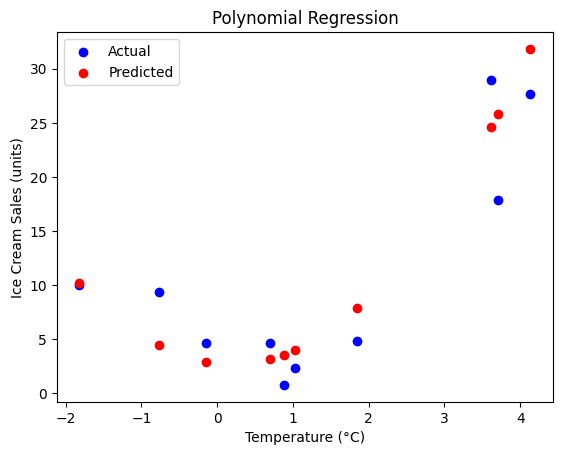

In [133]:
plt.scatter(X_test,y_test,color='blue',label="Actual")
plt.scatter(X_test, y_pred, color='red', label='Predicted')

plt.xlabel("Temperature (°C)")
plt.ylabel("Ice Cream Sales (units)")
plt.title("Polynomial Regression")
plt.legend()
plt.show()

In [134]:
train_score = model.score(X_train_poly, y_train)
test_score = model.score(X_test_poly, y_test)

print("Train R² Score:", train_score)
print("Test R² Score:", test_score)

Train R² Score: 0.9590068634754769
Test R² Score: 0.8054468908427623


# Conclusion
* A low value of MSE, RMSE, and MAE indicates that the prediction errors are small, 
* while an R² score closer to 1 indicates that the model explains a high percentage 
* of the variance in ice cream sales.